# Examen Practico - Primer Parcial
![Logo](itq.jpg)
#### Nombre: Santiago Carrasco  
#### Fecha: 1/7/2026

In [1]:
from pathlib import Path
import os

# Cambiar Jupyter a la carpeta principal del proyecto
proyecto = Path(r"C:\Users\ACER GAMER\Desktop\ipynb\ProyectoRayosX_solucion")

os.chdir(proyecto)

print("Ahora Jupyter está trabajando en:")
print(Path.cwd())

Ahora Jupyter está trabajando en:
C:\Users\ACER GAMER\Desktop\ipynb\ProyectoRayosX_solucion


### Paso 0.2: Instalar librerías necesarias

Se instalan las librerías que se usarán para procesar imágenes, calcular características y manejar datos.

In [2]:
!pip install opencv-python numpy pandas matplotlib scikit-image scipy

### Paso 0.3: Importar librerías

Se importan OpenCV, NumPy, Pandas, Matplotlib, SciPy y Scikit-image.

In [3]:
import os
import zipfile
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy import ndimage as ndi
from skimage.measure import label, regionprops
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, binary_closing, disk

try:
    from skimage.feature import graycomatrix, graycoprops
except:
    from skimage.feature import greycomatrix as graycomatrix
    from skimage.feature import greycoprops as graycoprops

### Paso 1: Crear estructura del proyecto

Se crean las carpetas data/raw, data/processed, notebooks, src y outputs/visualizaciones.

In [4]:
# Crear estructura principal del proyecto
carpetas = [
    "data/raw",
    "data/processed",
    "notebooks",
    "src",
    "outputs/visualizaciones"
]

for carpeta in carpetas:
    os.makedirs(carpeta, exist_ok=True)

print("Estructura de carpetas creada correctamente.")

Estructura de carpetas creada correctamente.


### Paso 3: Descomprimir el dataset

Se descomprime el archivo archive.zip dentro de la carpeta data/raw.

In [5]:
from pathlib import Path
import zipfile

raw_path = Path("data/raw")
zip_file = raw_path / "archive.zip"

if zip_file.exists():
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(raw_path)

    print("El archivo archive.zip se descomprimió correctamente en data/raw")
else:
    print("No se encontró archive.zip")
    print("Asegúrate de que esté en la carpeta data/raw")

El archivo archive.zip se descomprimió correctamente en data/raw


### Paso 4.1: Analizar estructura del dataset

Se define la ruta del dataset, se evitan imágenes duplicadas y se cuenta la cantidad de imágenes por conjunto y clase.

In [7]:
from pathlib import Path
import os

# Cambiar Jupyter a la carpeta principal del proyecto
proyecto = Path(r"C:\Users\ACER GAMER\Desktop\ipynb\ProyectoRayosX_solucion")
os.chdir(proyecto)

# Definir la ruta del dataset
dataset_path = Path("data/raw/chest_xray")

print("Carpeta actual:")
print(Path.cwd())

print("Ruta del dataset:")
print(dataset_path)

print("Existe train:", (dataset_path / "train").exists())
print("Existe test:", (dataset_path / "test").exists())
print("Existe val:", (dataset_path / "val").exists())

Carpeta actual:
C:\Users\ACER GAMER\Desktop\ipynb\ProyectoRayosX_solucion
Ruta del dataset:
data\raw\chest_xray
Existe train: True
Existe test: True
Existe val: True


In [8]:
import pandas as pd
from pathlib import Path

# Extensiones permitidas. Usamos suffix.lower() para evitar duplicados en Windows.
EXTENSIONES_VALIDAS = {".jpg", ".jpeg", ".png"}

def obtener_imagenes_unicas(carpeta):
    """
    Obtiene las imágenes de una carpeta sin duplicarlas.
    En Windows, buscar .jpeg y .JPEG puede devolver el mismo archivo dos veces,
    por eso se revisa la extensión con suffix.lower().
    """
    carpeta = Path(carpeta)
    imagenes = []
    vistos = set()

    for archivo in carpeta.iterdir():
        if archivo.is_file() and archivo.suffix.lower() in EXTENSIONES_VALIDAS:
            clave = str(archivo.resolve()).lower()

            if clave not in vistos:
                vistos.add(clave)
                imagenes.append(archivo)

    return sorted(imagenes, key=lambda x: str(x).lower())


resumen = []

for conjunto in ["train", "test", "val"]:
    conjunto_path = dataset_path / conjunto

    if conjunto_path.exists():
        clases = [
            c for c in conjunto_path.iterdir()
            if c.is_dir() and not c.name.startswith("__")
        ]

        for clase in clases:
            imagenes = obtener_imagenes_unicas(clase)

            resumen.append({
                "Conjunto": conjunto,
                "Clase": clase.name,
                "Cantidad de imágenes": len(imagenes)
            })

df_resumen = pd.DataFrame(resumen)
df_resumen


,Conjunto,Clase,Cantidad de imágenes
0,train,NORMAL,1341
1,train,PNEUMONIA,3875
2,test,NORMAL,234
3,test,PNEUMONIA,390
4,val,NORMAL,8
5,val,PNEUMONIA,8


### Paso 4.2: Mostrar número de clases

Se muestran las clases encontradas en el dataset, por ejemplo NORMAL y PNEUMONIA.

In [9]:
clases = df_resumen["Clase"].unique()

print("Número de clases:", len(clases))
print("Clases encontradas:", clases)

Número de clases: 2
Clases encontradas: ['NORMAL' 'PNEUMONIA']


### Paso 4.3: Contar imágenes por conjunto

Se calcula el total de imágenes en train, test y val.

In [10]:
df_resumen.groupby("Conjunto")["Cantidad de imágenes"].sum()

Conjunto
test      624
train    5216
val        16
Name: Cantidad de imágenes, dtype: int64

### Paso 4.4: Contar imágenes por clase

Se calcula el total de imágenes por cada clase del dataset.

In [11]:
df_resumen.groupby("Clase")["Cantidad de imágenes"].sum()

Clase
NORMAL       1583
PNEUMONIA    4273
Name: Cantidad de imágenes, dtype: int64

### Paso 6.1: Obtener una imagen de prueba

Se selecciona automáticamente una imagen para probar el procesamiento antes de ejecutar todo el dataset.

In [12]:
def obtener_primera_imagen(dataset_path):
    for conjunto in ["train", "test", "val"]:
        conjunto_path = dataset_path / conjunto

        if conjunto_path.exists():
            clases = [
                c for c in conjunto_path.iterdir()
                if c.is_dir() and not c.name.startswith("__")
            ]

            for clase in clases:
                imagenes = obtener_imagenes_unicas(clase)

                if len(imagenes) > 0:
                    return imagenes[0], conjunto, clase.name

    return None, None, None


imagen_prueba_path, conjunto_prueba, clase_prueba = obtener_primera_imagen(dataset_path)

print("Imagen encontrada:")
print(imagen_prueba_path)
print("Conjunto:", conjunto_prueba)
print("Clase:", clase_prueba)


Imagen encontrada:
data\raw\chest_xray\train\NORMAL\IM-0115-0001.jpeg
Conjunto: train
Clase: NORMAL


### Paso 6.2: Mostrar imagen original

Se carga una radiografía en escala de grises y se visualiza como imagen original.

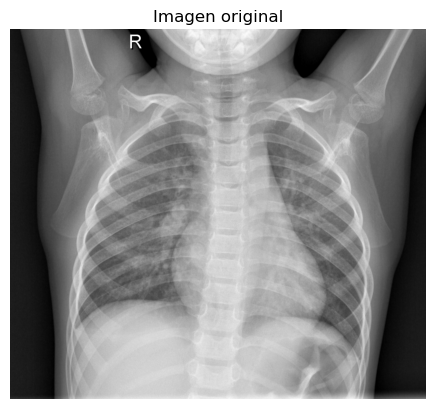

In [13]:
imagen = cv2.imread(str(imagen_prueba_path), cv2.IMREAD_GRAYSCALE)

plt.imshow(imagen, cmap="gray")
plt.title("Imagen original")
plt.axis("off")
plt.show()

### Paso 6.3: Preprocesar imagen

Se redimensiona, suaviza y mejora el contraste de la imagen.

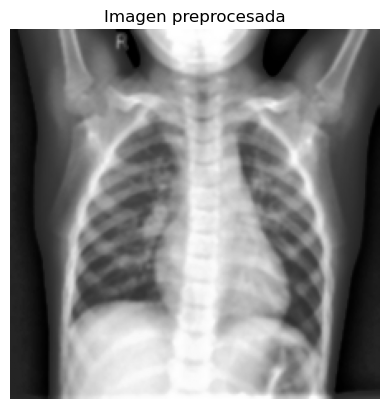

In [14]:
def preprocesar_imagen(imagen):
    # Redimensionar la imagen a 224x224
    imagen = cv2.resize(imagen, (224, 224))

    # Aplicar desenfoque para reducir ruido
    blur = cv2.GaussianBlur(imagen, (5, 5), 0)

    # Mejorar contraste
    ecualizada = cv2.equalizeHist(blur)

    return ecualizada


imagen_preprocesada = preprocesar_imagen(imagen)

plt.imshow(imagen_preprocesada, cmap="gray")
plt.title("Imagen preprocesada")
plt.axis("off")
plt.show()

### Paso 6.4: Segmentar ROI

Se obtiene la región de interés mediante umbralización, cierre morfológico, relleno de huecos y eliminación de objetos pequeños.

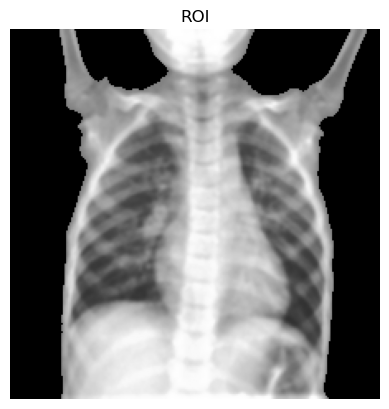

In [15]:
def segmentar_roi(imagen):
    # Calcular umbral automático
    umbral = threshold_otsu(imagen)

    # Crear máscara
    mascara = imagen > umbral

    # Cerrar espacios pequeños
    mascara = binary_closing(mascara, disk(3))

    # Rellenar huecos
    mascara = ndi.binary_fill_holes(mascara)

    # Eliminar objetos pequeños
    mascara = remove_small_objects(mascara, min_size=500)

    # Convertir máscara a uint8
    mascara_uint8 = mascara.astype(np.uint8) * 255

    # Aplicar máscara sobre la imagen
    roi = cv2.bitwise_and(imagen, imagen, mask=mascara_uint8)

    return mascara_uint8, roi


mascara, roi = segmentar_roi(imagen_preprocesada)

plt.imshow(roi, cmap="gray")
plt.title("ROI")
plt.axis("off")
plt.show()

### Paso 6.5: Extraer características de color

Se calculan intensidad media, mínima, máxima, desviación estándar, varianza, mediana, moda, percentiles e histograma.

In [16]:
def caracteristicas_color(imagen):
    pixeles = imagen.flatten()

    histograma, _ = np.histogram(pixeles, bins=16, range=(0, 256))

    valores, conteos = np.unique(pixeles, return_counts=True)
    moda = valores[np.argmax(conteos)]

    datos = {
        "intensidad_media": np.mean(pixeles),
        "intensidad_minima": np.min(pixeles),
        "intensidad_maxima": np.max(pixeles),
        "desviacion_estandar": np.std(pixeles),
        "varianza": np.var(pixeles),
        "mediana": np.median(pixeles),
        "moda": moda,
        "percentil_25": np.percentile(pixeles, 25),
        "percentil_75": np.percentile(pixeles, 75)
    }

    for i, valor in enumerate(histograma):
        datos[f"histograma_bin_{i}"] = valor

    return datos


color = caracteristicas_color(imagen_preprocesada)
color

{'intensidad_media': np.float64(128.05480707908163),
 'intensidad_minima': np.uint8(0),
 'intensidad_maxima': np.uint8(255),
 'desviacion_estandar': np.float64(73.73545684183341),
 'varianza': np.float64(5436.917595673877),
 'mediana': np.float64(128.0),
 'moda': np.uint8(34),
 'percentil_25': np.float64(64.0),
 'percentil_75': np.float64(191.0),
 'histograma_bin_0': np.int64(3088),
 'histograma_bin_1': np.int64(3020),
 'histograma_bin_2': np.int64(3209),
 'histograma_bin_3': np.int64(3100),
 'histograma_bin_4': np.int64(3132),
 'histograma_bin_5': np.int64(3101),
 'histograma_bin_6': np.int64(3046),
 'histograma_bin_7': np.int64(3169),
 'histograma_bin_8': np.int64(3367),
 'histograma_bin_9': np.int64(2920),
 'histograma_bin_10': np.int64(3228),
 'histograma_bin_11': np.int64(3313),
 'histograma_bin_12': np.int64(3076),
 'histograma_bin_13': np.int64(2999),
 'histograma_bin_14': np.int64(3325),
 'histograma_bin_15': np.int64(3083)}

### Paso 6.6: Mostrar histograma

Se muestra el histograma de intensidades de la imagen preprocesada.

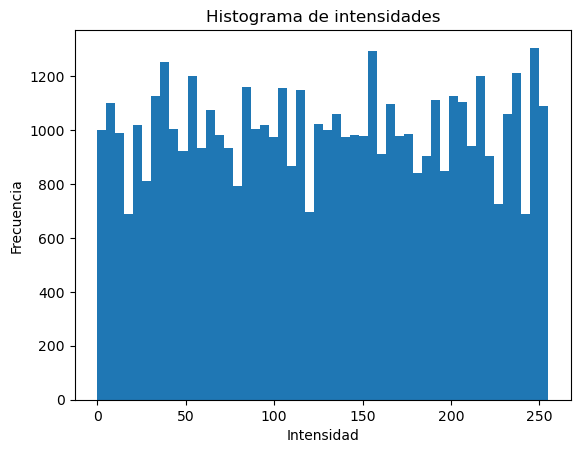

In [17]:
plt.hist(imagen_preprocesada.flatten(), bins=50)
plt.title("Histograma de intensidades")
plt.xlabel("Intensidad")
plt.ylabel("Frecuencia")
plt.show()

### Paso 6.7: Extraer características de forma

Se calculan área, perímetro, circularidad, compacidad, bounding box, aspect ratio, solidity, extent, convex hull y centroide.

In [18]:
def caracteristicas_forma(mascara):
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contornos) == 0:
        return {
            "area": 0,
            "perimetro": 0,
            "circularidad": 0,
            "compacidad": 0,
            "bbox_x": 0,
            "bbox_y": 0,
            "bbox_w": 0,
            "bbox_h": 0,
            "aspect_ratio": 0,
            "solidity": 0,
            "extent": 0,
            "convex_hull_area": 0,
            "centroide_x": 0,
            "centroide_y": 0
        }

    contorno = max(contornos, key=cv2.contourArea)

    area = cv2.contourArea(contorno)
    perimetro = cv2.arcLength(contorno, True)

    circularidad = 4 * np.pi * area / (perimetro ** 2) if perimetro > 0 else 0
    compacidad = (perimetro ** 2) / area if area > 0 else 0

    x, y, w, h = cv2.boundingRect(contorno)
    bbox_area = w * h

    aspect_ratio = w / h if h > 0 else 0
    extent = area / bbox_area if bbox_area > 0 else 0

    hull = cv2.convexHull(contorno)
    convex_hull_area = cv2.contourArea(hull)
    solidity = area / convex_hull_area if convex_hull_area > 0 else 0

    momentos = cv2.moments(contorno)

    if momentos["m00"] != 0:
        cx = momentos["m10"] / momentos["m00"]
        cy = momentos["m01"] / momentos["m00"]
    else:
        cx = 0
        cy = 0

    return {
        "area": area,
        "perimetro": perimetro,
        "circularidad": circularidad,
        "compacidad": compacidad,
        "bbox_x": x,
        "bbox_y": y,
        "bbox_w": w,
        "bbox_h": h,
        "aspect_ratio": aspect_ratio,
        "solidity": solidity,
        "extent": extent,
        "convex_hull_area": convex_hull_area,
        "centroide_x": cx,
        "centroide_y": cy
    }


forma = caracteristicas_forma(mascara)
forma

{'area': 31804.5,
 'perimetro': 1004.7422020435333,
 'circularidad': 0.3959033238376296,
 'compacidad': 31.7410081141753,
 'bbox_x': 30,
 'bbox_y': 0,
 'bbox_w': 186,
 'bbox_h': 224,
 'aspect_ratio': 0.8303571428571429,
 'solidity': 0.8238654025489587,
 'extent': 0.7633568548387096,
 'convex_hull_area': 38604.0,
 'centroide_x': 113.88974306570871,
 'centroide_y': 121.30153489810142}

### Paso 6.8: Extraer características de textura

Se usa la matriz GLCM para obtener contraste, homogeneidad, correlación, energía, ASM, disimilitud y entropía.

In [19]:
def caracteristicas_textura(imagen):
    imagen_reducida = (imagen / 32).astype(np.uint8)

    glcm = graycomatrix(
        imagen_reducida,
        distances=[1],
        angles=[0],
        levels=8,
        symmetric=True,
        normed=True
    )

    contraste = graycoprops(glcm, "contrast")[0, 0]
    homogeneidad = graycoprops(glcm, "homogeneity")[0, 0]
    correlacion = graycoprops(glcm, "correlation")[0, 0]
    energia = graycoprops(glcm, "energy")[0, 0]
    asm = graycoprops(glcm, "ASM")[0, 0]
    disimilitud = graycoprops(glcm, "dissimilarity")[0, 0]

    matriz = glcm[:, :, 0, 0]
    entropia = -np.sum(matriz * np.log2(matriz + 1e-10))

    return {
        "contraste": contraste,
        "homogeneidad": homogeneidad,
        "correlacion": correlacion,
        "energia": energia,
        "asm": asm,
        "disimilitud": disimilitud,
        "entropia_textura": entropia
    }


textura = caracteristicas_textura(imagen_preprocesada)
textura

{'contraste': np.float64(0.15817184497117232),
 'homogeneidad': np.float64(0.9220191383728379),
 'correlacion': np.float64(0.9848398107186065),
 'energia': np.float64(0.3025225367388764),
 'asm': np.float64(0.09151988523492482),
 'disimilitud': np.float64(0.15633007687379885),
 'entropia_textura': np.float64(3.7421913583343716)}

### Paso 6.9: Extraer características de bordes

Se aplican Sobel, Canny y Laplaciano, y se calcula número de bordes, densidad y longitud promedio.

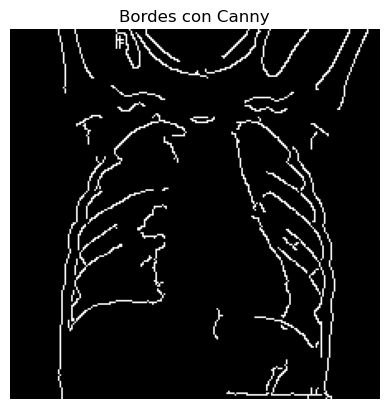

In [20]:
def caracteristicas_bordes(imagen):
    # Operador Sobel
    sobel_x = cv2.Sobel(imagen, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(imagen, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.sqrt(sobel_x**2 + sobel_y**2)

    # Operador Canny
    canny = cv2.Canny(imagen, 100, 200)

    # Operador Laplaciano
    laplaciano = cv2.Laplacian(imagen, cv2.CV_64F)

    # Número de bordes
    numero_bordes = np.count_nonzero(canny)

    # Densidad de bordes
    densidad_bordes = numero_bordes / canny.size

    # Longitud promedio de bordes
    etiquetas = label(canny > 0)
    regiones = regionprops(etiquetas)

    if len(regiones) > 0:
        longitud_promedio = np.mean([r.area for r in regiones])
    else:
        longitud_promedio = 0

    datos = {
        "sobel_media": np.mean(sobel),
        "laplaciano_media": np.mean(np.abs(laplaciano)),
        "numero_bordes": numero_bordes,
        "densidad_bordes": densidad_bordes,
        "longitud_promedio_bordes": longitud_promedio
    }

    return datos, canny


bordes, imagen_bordes = caracteristicas_bordes(imagen_preprocesada)
bordes
plt.imshow(imagen_bordes, cmap="gray")
plt.title("Bordes con Canny")
plt.axis("off")
plt.show()

### Paso 6.10: Extraer características morfológicas

Se calculan número de objetos, regiones, áreas, excentricidad, eje mayor, eje menor y orientación.

In [21]:
def caracteristicas_morfologicas(mascara):
    etiquetas = label(mascara > 0)
    regiones = regionprops(etiquetas)

    if len(regiones) == 0:
        return {
            "numero_objetos": 0,
            "numero_regiones": 0,
            "area_promedio": 0,
            "area_maxima": 0,
            "area_minima": 0,
            "excentricidad": 0,
            "eje_mayor": 0,
            "eje_menor": 0,
            "orientacion": 0
        }

    areas = [r.area for r in regiones]

    # Se toma la región más grande como región principal
    region_principal = max(regiones, key=lambda r: r.area)

    datos = {
        "numero_objetos": len(regiones),
        "numero_regiones": len(regiones),
        "area_promedio": np.mean(areas),
        "area_maxima": np.max(areas),
        "area_minima": np.min(areas),
        "excentricidad": region_principal.eccentricity,
        "eje_mayor": region_principal.major_axis_length,
        "eje_menor": region_principal.minor_axis_length,
        "orientacion": region_principal.orientation
    }

    return datos


morfologia = caracteristicas_morfologicas(mascara)
morfologia

{'numero_objetos': 1,
 'numero_regiones': 1,
 'area_promedio': np.float64(32265.0),
 'area_maxima': np.float64(32265.0),
 'area_minima': np.float64(32265.0),
 'excentricidad': 0.6664285388203366,
 'eje_mayor': 244.7929739841403,
 'eje_menor': 182.51003129582523,
 'orientacion': -0.05852257775827705}

### Paso 6.11: Extraer características frecuenciales

Se aplica la Transformada Rápida de Fourier y se calculan magnitud máxima, frecuencia dominante, energía, centroide y entropía espectral.

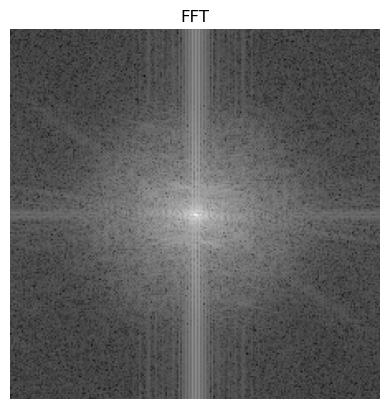

In [22]:
def caracteristicas_fft(imagen):
    # Aplicar FFT
    fft = np.fft.fft2(imagen)

    # Centrar las frecuencias
    fft_shift = np.fft.fftshift(fft)

    # Obtener magnitud
    magnitud = np.abs(fft_shift)

    filas, columnas = magnitud.shape
    centro_y = filas // 2
    centro_x = columnas // 2

    # Quitar el centro para buscar la frecuencia dominante
    magnitud_sin_centro = magnitud.copy()
    magnitud_sin_centro[centro_y, centro_x] = 0

    indice_max = np.unravel_index(
        np.argmax(magnitud_sin_centro),
        magnitud_sin_centro.shape
    )

    frecuencia_dominante = np.sqrt(
        (indice_max[0] - centro_y) ** 2 +
        (indice_max[1] - centro_x) ** 2
    )

    energia_espectral = np.sum(magnitud ** 2)

    y, x = np.indices(magnitud.shape)
    distancias = np.sqrt((y - centro_y) ** 2 + (x - centro_x) ** 2)

    centroide_espectral = np.sum(distancias * magnitud) / (np.sum(magnitud) + 1e-10)

    probabilidad = magnitud / (np.sum(magnitud) + 1e-10)
    entropia_espectral = -np.sum(probabilidad * np.log2(probabilidad + 1e-10))

    datos = {
        "magnitud_maxima": np.max(magnitud),
        "frecuencia_dominante": frecuencia_dominante,
        "energia_espectral": energia_espectral,
        "centroide_espectral": centroide_espectral,
        "entropia_espectral": entropia_espectral
    }

    return datos, magnitud


fft_caracteristicas, imagen_fft = caracteristicas_fft(imagen_preprocesada)
fft_caracteristicas

plt.imshow(np.log1p(imagen_fft), cmap="gray")
plt.title("FFT")
plt.axis("off")
plt.show()

### Paso 6.12: Calcular momentos de Hu

Se calculan los siete momentos invariantes de Hu de la máscara segmentada.

In [23]:
def momentos_hu(mascara):
    momentos = cv2.moments(mascara)
    hu = cv2.HuMoments(momentos).flatten()

    # Se aplica logaritmo para que los valores sean más fáciles de manejar
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

    datos = {}

    for i in range(7):
        datos[f"hu_momento_{i+1}"] = hu_log[i]

    return datos


hu = momentos_hu(mascara)
hu

{'hu_momento_1': np.float64(3.1498197290036707),
 'hu_momento_2': np.float64(7.38751225049803),
 'hu_momento_3': np.float64(9.989797262990281),
 'hu_momento_4': np.float64(9.994949972071865),
 'hu_momento_5': np.float64(9.999999999999991),
 'hu_momento_6': np.float64(9.99999897311569),
 'hu_momento_7': np.float64(-9.999999999999996)}

### Paso 6.13: Unir todas las características

Se crea una función que procesa una imagen y reúne todas sus características en un solo vector.

In [24]:
def extraer_caracteristicas_imagen(ruta_imagen, conjunto, clase):
    imagen = cv2.imread(str(ruta_imagen), cv2.IMREAD_GRAYSCALE)

    if imagen is None:
        return None

    # Preprocesamiento
    imagen_pre = preprocesar_imagen(imagen)

    # Segmentación ROI
    mascara, roi = segmentar_roi(imagen_pre)

    datos = {
        "imagen": ruta_imagen.name,
        "ruta": str(ruta_imagen),
        "conjunto": conjunto,
        "clase": clase
    }

    # Características de color
    datos.update(caracteristicas_color(imagen_pre))

    # Características de forma
    datos.update(caracteristicas_forma(mascara))

    # Características de textura
    datos.update(caracteristicas_textura(imagen_pre))

    # Características de bordes
    datos_bordes, canny = caracteristicas_bordes(imagen_pre)
    datos.update(datos_bordes)

    # Características morfológicas
    datos.update(caracteristicas_morfologicas(mascara))

    # Características frecuenciales
    datos_fft, magnitud_fft = caracteristicas_fft(imagen_pre)
    datos.update(datos_fft)

    # Momentos de Hu
    datos.update(momentos_hu(mascara))

    return datos

### Paso 6.14: Probar extracción de características

Se prueba la función anterior usando una sola imagen antes de procesar todo el dataset.

In [25]:
caracteristicas_prueba = extraer_caracteristicas_imagen(
    imagen_prueba_path,
    conjunto_prueba,
    clase_prueba
)

caracteristicas_prueba

{'imagen': 'IM-0115-0001.jpeg',
 'ruta': 'data\\raw\\chest_xray\\train\\NORMAL\\IM-0115-0001.jpeg',
 'conjunto': 'train',
 'clase': 'NORMAL',
 'intensidad_media': np.float64(128.05480707908163),
 'intensidad_minima': np.uint8(0),
 'intensidad_maxima': np.uint8(255),
 'desviacion_estandar': np.float64(73.73545684183341),
 'varianza': np.float64(5436.917595673877),
 'mediana': np.float64(128.0),
 'moda': np.uint8(34),
 'percentil_25': np.float64(64.0),
 'percentil_75': np.float64(191.0),
 'histograma_bin_0': np.int64(3088),
 'histograma_bin_1': np.int64(3020),
 'histograma_bin_2': np.int64(3209),
 'histograma_bin_3': np.int64(3100),
 'histograma_bin_4': np.int64(3132),
 'histograma_bin_5': np.int64(3101),
 'histograma_bin_6': np.int64(3046),
 'histograma_bin_7': np.int64(3169),
 'histograma_bin_8': np.int64(3367),
 'histograma_bin_9': np.int64(2920),
 'histograma_bin_10': np.int64(3228),
 'histograma_bin_11': np.int64(3313),
 'histograma_bin_12': np.int64(3076),
 'histograma_bin_13': np.

### Paso 6.15: Guardar visualizaciones

Se crea una función para guardar imagen original, preprocesada, ROI, bordes, histograma y FFT.

In [26]:
def guardar_visualizaciones(ruta_imagen, conjunto, clase):
    salida = Path("outputs/visualizaciones")
    salida.mkdir(parents=True, exist_ok=True)

    imagen = cv2.imread(str(ruta_imagen), cv2.IMREAD_GRAYSCALE)

    if imagen is None:
        print("No se pudo cargar la imagen.")
        return

    imagen_pre = preprocesar_imagen(imagen)
    mascara, roi = segmentar_roi(imagen_pre)
    datos_bordes, canny = caracteristicas_bordes(imagen_pre)
    datos_fft, magnitud_fft = caracteristicas_fft(imagen_pre)

    nombre_base = f"{conjunto}_{clase}_{ruta_imagen.stem}"

    # Guardar imagen original
    plt.imsave(salida / f"{nombre_base}_original.png", imagen, cmap="gray")

    # Guardar imagen preprocesada
    plt.imsave(salida / f"{nombre_base}_preprocesada.png", imagen_pre, cmap="gray")

    # Guardar ROI
    plt.imsave(salida / f"{nombre_base}_roi.png", roi, cmap="gray")

    # Guardar bordes
    plt.imsave(salida / f"{nombre_base}_bordes.png", canny, cmap="gray")

    # Guardar FFT
    plt.imsave(salida / f"{nombre_base}_fft.png", np.log1p(magnitud_fft), cmap="gray")

    # Guardar histograma
    plt.figure()
    plt.hist(imagen_pre.flatten(), bins=50)
    plt.title("Histograma de intensidades")
    plt.xlabel("Intensidad")
    plt.ylabel("Frecuencia")
    plt.savefig(salida / f"{nombre_base}_histograma.png")
    plt.close()

    print("Visualizaciones guardadas correctamente.")

### Paso 6.16: Ejecutar visualizaciones de ejemplo

Se generan y guardan las visualizaciones de la imagen de prueba.

In [27]:
guardar_visualizaciones(imagen_prueba_path, conjunto_prueba, clase_prueba)

Visualizaciones guardadas correctamente.


### Paso 6.17: Definir cantidad de imágenes a procesar

Se define si se procesan todas las imágenes o solo una cantidad de prueba.

In [28]:
MAX_IMAGES_PER_CLASS = None

### Paso 6.18: Procesar el dataset completo

Se recorren las carpetas train, test y val, se extraen características y se evita duplicar imágenes.

In [29]:
datos_finales = []

for conjunto in ["train", "test", "val"]:
    conjunto_path = dataset_path / conjunto

    if not conjunto_path.exists():
        continue

    clases = [
        c for c in conjunto_path.iterdir()
        if c.is_dir() and not c.name.startswith("__")
    ]

    for clase_path in clases:
        clase = clase_path.name

        # Aquí se usa la función corregida para no duplicar imágenes
        imagenes = obtener_imagenes_unicas(clase_path)

        if MAX_IMAGES_PER_CLASS is not None:
            imagenes = imagenes[:MAX_IMAGES_PER_CLASS]

        print(f"Procesando {conjunto} - {clase}: {len(imagenes)} imágenes")

        for i, ruta_imagen in enumerate(imagenes, start=1):
            caracteristicas = extraer_caracteristicas_imagen(
                ruta_imagen,
                conjunto,
                clase
            )

            if caracteristicas is not None:
                datos_finales.append(caracteristicas)

            # Mensaje cada 100 imágenes para saber que sigue trabajando
            if i % 100 == 0 or i == len(imagenes):
                print(f"  {i}/{len(imagenes)} imágenes procesadas")

print("Proceso terminado.")
print("Total de imágenes procesadas:", len(datos_finales))


Procesando train - NORMAL: 1341 imágenes
  100/1341 imágenes procesadas
  200/1341 imágenes procesadas
  300/1341 imágenes procesadas
  400/1341 imágenes procesadas
  500/1341 imágenes procesadas
  600/1341 imágenes procesadas
  700/1341 imágenes procesadas
  800/1341 imágenes procesadas
  900/1341 imágenes procesadas
  1000/1341 imágenes procesadas
  1100/1341 imágenes procesadas
  1200/1341 imágenes procesadas
  1300/1341 imágenes procesadas
  1341/1341 imágenes procesadas
Procesando train - PNEUMONIA: 3875 imágenes
  100/3875 imágenes procesadas
  200/3875 imágenes procesadas
  300/3875 imágenes procesadas
  400/3875 imágenes procesadas
  500/3875 imágenes procesadas
  600/3875 imágenes procesadas
  700/3875 imágenes procesadas
  800/3875 imágenes procesadas
  900/3875 imágenes procesadas
  1000/3875 imágenes procesadas
  1100/3875 imágenes procesadas
  1200/3875 imágenes procesadas
  1300/3875 imágenes procesadas
  1400/3875 imágenes procesadas
  1500/3875 imágenes procesadas
  160

### Paso 6.19: Crear DataFrame y eliminar duplicados

Se convierte la lista de características en un DataFrame y se eliminan rutas repetidas antes de guardar.

In [30]:
df_features = pd.DataFrame(datos_finales)

# Seguridad extra: eliminar duplicados por ruta antes de guardar
if not df_features.empty and "ruta" in df_features.columns:
    filas_antes = df_features.shape[0]
    df_features = df_features.drop_duplicates(subset=["ruta"]).reset_index(drop=True)
    filas_despues = df_features.shape[0]

    print("Filas antes de eliminar duplicados:", filas_antes)
    print("Filas después de eliminar duplicados:", filas_despues)
    print("Duplicados eliminados:", filas_antes - filas_despues)

df_features.head()


Filas antes de eliminar duplicados: 5856
Filas después de eliminar duplicados: 5856
Duplicados eliminados: 0


,imagen,ruta,conjunto,clase,intensidad_media,intensidad_minima,intensidad_maxima,desviacion_estandar,varianza,mediana,...,energia_espectral,centroide_espectral,entropia_espectral,hu_momento_1,hu_momento_2,hu_momento_3,hu_momento_4,hu_momento_5,hu_momento_6,hu_momento_7
0,IM-0115-0001.jpeg,data\raw\chest_xray\train\NORMAL\IM-0115-0001....,train,NORMAL,128.054807,0,255,73.735457,5436.917596,128.0,...,5.497235e+13,25.879360,11.826923,3.149820,7.387512,9.989797,9.994950,10.0,9.999999,-10.0
1,IM-0117-0001.jpeg,data\raw\chest_xray\train\NORMAL\IM-0117-0001....,train,NORMAL,119.669483,0,255,77.933856,6073.685880,119.0,...,5.134575e+13,24.402864,11.889919,3.165680,7.487573,9.895163,9.999355,10.0,10.000000,10.0
2,IM-0119-0001.jpeg,data\raw\chest_xray\train\NORMAL\IM-0119-0001....,train,NORMAL,117.207988,0,255,79.151028,6264.885233,117.0,...,5.035916e+13,24.640023,11.761080,3.150280,7.214352,9.846604,9.997503,10.0,9.999999,-10.0
3,IM-0122-0001.jpeg,data\raw\chest_xray\train\NORMAL\IM-0122-0001....,train,NORMAL,128.258032,0,255,73.725183,5435.402628,129.0,...,5.509968e+13,24.446970,11.674279,3.156007,7.273647,9.956796,9.998998,10.0,10.000000,10.0
4,IM-0125-0001.jpeg,data\raw\chest_xray\train\NORMAL\IM-0125-0001....,train,NORMAL,114.423031,0,255,80.126093,6420.190783,113.0,...,4.912608e+13,24.932429,11.924369,3.169780,7.569920,9.931993,9.999959,-10.0,-10.000000,-10.0


### Paso 6.20: Guardar dataset final

Se guarda el archivo final Dataset_feature.csv dentro de data/processed.

In [31]:
salida_csv = "data/processed/Dataset_feature.csv"

df_features.to_csv(salida_csv, index=False)

print("Dataset final guardado en:")
print(salida_csv)

Dataset final guardado en:
data/processed/Dataset_feature.csv


### Paso 6.21: Verificar filas y columnas

Se muestra el tamaño final del dataset generado.

In [32]:
print("Filas:", df_features.shape[0])
print("Columnas:", df_features.shape[1])

Filas: 5856
Columnas: 76


### Paso 6.22: Verificar clases procesadas

Se muestra cuántas imágenes quedaron procesadas por cada clase.

In [33]:
df_features["clase"].value_counts()

clase
PNEUMONIA    4273
NORMAL       1583
Name: count, dtype: int64